In [ ]:
import pandas as pd
import sys

In [ ]:
sys.path.insert(0, '')
from Clase_Valor import Valor
from Transversal import leer_activos, leer_parametros, leer_configuracion

In [ ]:
carpeta_input, cofre, seguimiento, saving_step = leer_parametros()
output_level = leer_configuracion()

In [ ]:
df_activos = leer_activos(carpeta_input)
df_activos

In [ ]:
simbolo, nombre = 'BRK-A', 'Berkshire Hathaway'

In [134]:
valor = Valor(simbolo, nombre, cofre) # Si no existe el objeto, se crea 
valor.extraer_data()
valor.ajustar_data()
df_rendimientos = valor.adj_data
df_rendimientos

[*********************100%***********************]  1 of 1 completed
Ejemplo funcional "date" con pandas nuevo


,Date,t,Open,High,Low,Close,Volume,rendimiento
0,1980-03-17,-15995,0.000391,0.000418,0.000391,0.000391,0.003649,NaN
1,1980-03-18,-15994,0.000391,0.000391,0.000391,0.000391,0.000000,0.000000
2,1980-03-19,-15993,0.000391,0.000418,0.000391,0.000391,0.007299,0.000000
3,1980-03-20,-15992,0.000391,0.000391,0.000391,0.000391,0.000000,0.000000
4,1980-03-21,-15991,0.000391,0.000391,0.000391,0.000391,0.000000,0.000000
...,...,...,...,...,...,...,...,...
16204,2024-07-28,209,0.884212,0.889341,0.879749,0.886513,0.000657,0.000446
16205,2024-07-29,210,0.886244,0.890197,0.880816,0.886908,0.000730,0.000446
16206,2024-07-30,211,0.888280,0.897639,0.886467,0.892387,0.000584,0.006177
16207,2024-07-31,212,0.892102,0.892102,0.885694,0.888459,0.000547,-0.004401


In [135]:
df_rendimientos = df_rendimientos[df_rendimientos['Date'] >= "2023-11-01"]

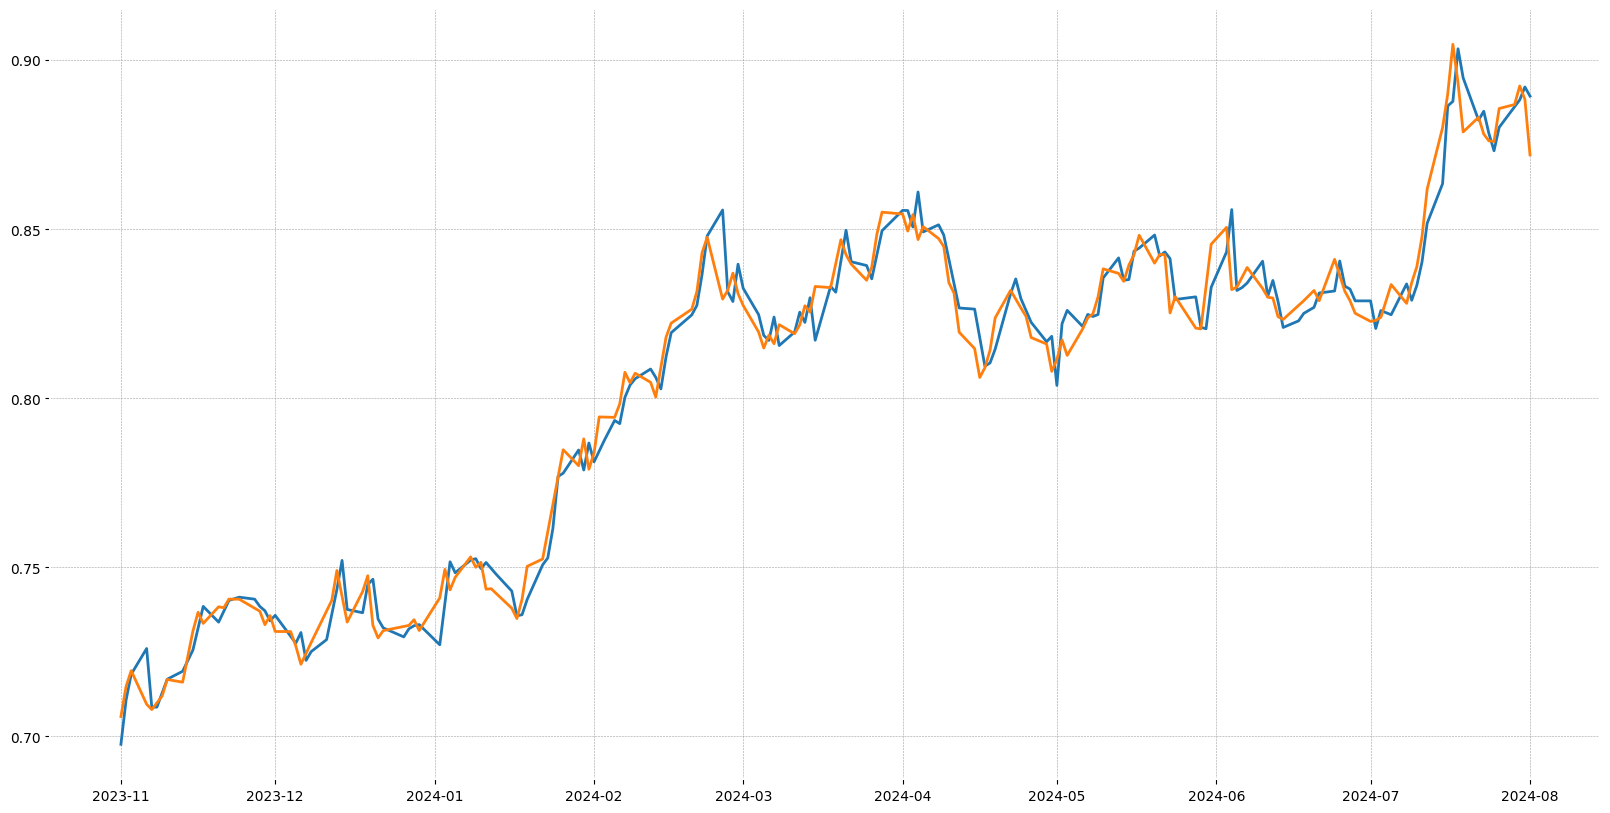

In [136]:
# graficar
import matplotlib.pyplot as plt
plt.figure(figsize = (20, 10))
plt.plot(df_rendimientos['Date'], df_rendimientos['Open'])
plt.plot(df_rendimientos['Date'], df_rendimientos['Close'])
plt.show()



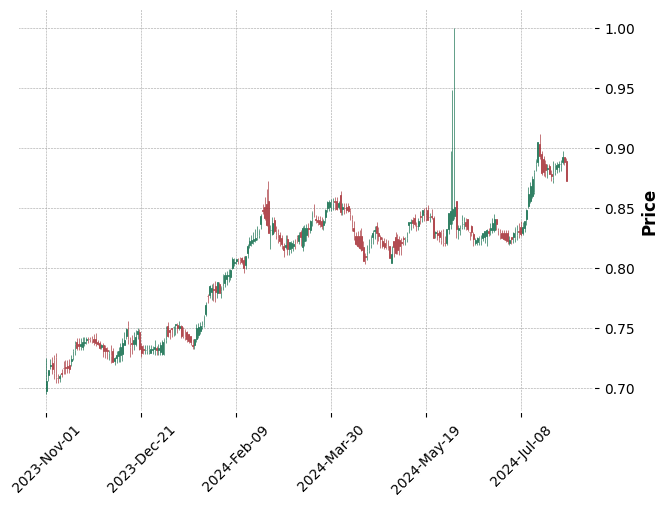

In [137]:
import pandas as pd
import mplfinance as mpf

# Supongamos que tienes un DataFrame 'df' con las siguientes columnas: 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'
# Aquí hay un ejemplo de cómo podría verse:

df_rendimientos['Date'] = pd.to_datetime(df_rendimientos['Date'])
df_rendimientos.set_index('Date', inplace=True)

# Crear el gráfico de velas
mpf.plot(df_rendimientos, type='candle', volume=False, style='charles')


In [138]:
df_rendimientos

,t,Open,High,Low,Close,Volume,rendimiento
Date,,,,,,,
2023-11-01,-61,0.697685,0.725096,0.695338,0.705889,0.002701,0.011440
2023-11-02,-60,0.710758,0.715392,0.705824,0.714772,0.002591,0.012584
2023-11-03,-59,0.718400,0.724509,0.715694,0.719455,0.002919,0.006552
2023-11-04,-58,0.720935,0.726117,0.711733,0.716147,0.003309,-0.004599
2023-11-05,-57,0.723469,0.727724,0.707772,0.712838,0.003698,-0.004620
...,...,...,...,...,...,...,...
2024-07-28,209,0.884212,0.889341,0.879749,0.886513,0.000657,0.000446
2024-07-29,210,0.886244,0.890197,0.880816,0.886908,0.000730,0.000446
2024-07-30,211,0.888280,0.897639,0.886467,0.892387,0.000584,0.006177


# Problema de las áreas

In [139]:
capos_modo_vela = {'area': ['Open', 'Close'], 'extremos': ['Low', 'High']}
modo_vela = 'area' # area o extremos


df = df_rendimientos[['t'] + capos_modo_vela[modo_vela]].reset_index()
df

,Date,t,Open,Close
0,2023-11-01,-61,0.697685,0.705889
1,2023-11-02,-60,0.710758,0.714772
2,2023-11-03,-59,0.718400,0.719455
3,2023-11-04,-58,0.720935,0.716147
4,2023-11-05,-57,0.723469,0.712838
...,...,...,...,...
270,2024-07-28,209,0.884212,0.886513
271,2024-07-29,210,0.886244,0.886908
272,2024-07-30,211,0.888280,0.892387
273,2024-07-31,212,0.892102,0.888459


In [140]:
X0 = df[['t', capos_modo_vela[modo_vela][0]]].rename(columns = {capos_modo_vela[modo_vela][0]: 'y'})
X1 = df[['t', capos_modo_vela[modo_vela][1]]].rename(columns = {capos_modo_vela[modo_vela][1]: 'y'})

X = pd.concat([X0, X1], axis = 0)
#X = X.rename(columns = {'t': 'x'}).reset_index(drop = True)
X # Tod la nube de puntos del problema

,t,y
0,-61,0.697685
1,-60,0.710758
2,-59,0.718400
3,-58,0.720935
4,-57,0.723469
...,...,...
270,209,0.886513
271,210,0.886908
272,211,0.892387
273,212,0.888459


In [141]:
def crear_dic_t_incial(df, K):
    t_min, t_max = df['t'].min(), df['t'].max()
    dic_t = {}
    for k in range(K + 1):
        t = t_min + k * (t_max - t_min) / K
        dic_t[k] = round(t)
    return dic_t

In [142]:
import matplotlib.pyplot as plt

In [143]:
# Graficar los datos en X, pinta de un color distinto según k_grupo

def graficar(X, K, dic_puntos = {}, dic_t = {}, titulo = ""):
    
    if len(dic_t) > 0:
        X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
        X = X.sort_values(by = 't').reset_index(drop = True)
    
    plt.figure(figsize = (10, 5))
    grupos = X['k'].unique()
    for k in grupos:
        X_k = X[X['k'] == k]
        plt.plot(X_k['t'], X_k['y'], 'o', label = f'Grupo {k}', c = plt.cm.tab10(k), markersize = 2) # markersize: tamaño de los puntos
    
        if k not in dic_puntos:
            continue    
        B0L, B1L, B0U, B1U = dic_puntos[k]['B0L'], dic_puntos[k]['B1L'], dic_puntos[k]['B0U'], dic_puntos[k]['B1U']
        plt.plot([X_k['t'].min(), X_k['t'].max()], [B0L + B1L * X_k['t'].min(), B0L + B1L * X_k['t'].max()], c = 'r')
        plt.plot([X_k['t'].min(), X_k['t'].max()], [B0U + B1U * X_k['t'].min(), B0U + B1U * X_k['t'].max()], c = 'g')
    
    if titulo != "":
        plt.title(titulo)
    plt.show()

In [144]:
import mip
# 1. generate_figure
def generate_all_figure(data_points, dic_t, gamma, output = True, slope_inf = 'libre', slope_sup = 'libre', paralelas = False, segmentos_conjuntos = True):

    '''
    :param data_points: Nube de puntos con los campos k | x | y, donde k es el grupo al que pertenece
    :param dic_t: Diccionario con los límites de los grupos
    :param gamma: Peso de las holguras
    :type: dataframe
    '''

    # CONFIGURACION
    
    # figura libre: libre, libre, False
    # canal: libre, libre, True
    # arriba pendiente 0: 0, libre, False
    # abajo pendiente 0: libre, 0, False
    # arriba y abajo pendiente 0: 0, 0, False/True

    output_vars = False
    data_points = data_points.reset_index(drop = True)
    
    grupos = data_points['k'].unique()
    
    mip_model = mip.Model()
    # Variables
    variables = {}
    for k in grupos:
        for v in ['B0L', 'B1L', 'B0U', 'B1U', 'HU', 'HL']: # HU & HL son las holguras en los grupos
            if v in ['HU', 'HL']:
                variables[f'G{k}_{v}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_{v}') # C: Continuas >= 0
            else:
                variables[f'G{k}_{v}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_{v}', lb = - float('inf')) 
        
    # Restriccion de puntos
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        for i in range(len(data_k)):
            t, y = data_k['t'][i], data_k['y'][i]
            #y = data_k['y'][i]
            
            variables[f'G{k}_HU_{i}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_HU_{i}') # C: Continuas
            variables[f'G{k}_HL_{i}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_HL_{i}') # C: Continuas

            R1 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t >= y - variables[f'G{k}_HU_{i}']) # Se incluyen las holguras
            R2 = (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t <= y + variables[f'G{k}_HL_{i}'])
            
            # independiente de las holguras, la recta superior debeestar siempre sobre la inferior
            R3 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t >= variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t)
            
            mip_model += R1
            mip_model += R2
            mip_model += R3


    # Restricciones de figuras
    if slope_inf == '0':
        for k in grupos:
            R4A = (variables[f'G{k}_B1L'] == 0)
            mip_model += R4A
    if slope_sup == '0':
        for k in grupos:
            R4B = (variables[f'G{k}_B1U'] == 0)
            mip_model += R4B
    if paralelas:
        for k in grupos:
            R4C = (variables[f'G{k}_B1L'] == variables[f'G{k}_B1U'])
            mip_model += R4C
            
    # Restricciones de segmentos conjuntos
    
    #sys.exit()
    for k in grupos:
        if not segmentos_conjuntos:
            break
        if k == max(grupos): # EL último límite no es contemplado
            break
        
        R5 = (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * dic_t[k] == variables[f'G{k + 1}_B0L'] + variables[f'G{k + 1}_B1L'] * dic_t[k])
        mip_model += R5
        R6 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * dic_t[k] == variables[f'G{k + 1}_B0U'] + variables[f'G{k + 1}_B1U'] * dic_t[k])
        mip_model += R6
    
    # Naturaleza de las variables de holgura
    """
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        for i in range(len(data_k)):
            R7 = (variables[f'G{k}_HU_{i}'] >= 0)
            mip_model += R7
            R8 = (variables[f'G{k}_HL_{i}'] >= 0)
            mip_model += R8
    """
        
    # Holgura total
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        R9 = (variables[f'G{k}_HU'] == sum([variables[f'G{k}_HU_{i}'] for i in range(len(data_k))]))
        mip_model += R9
        R10 = (variables[f'G{k}_HL'] == sum([variables[f'G{k}_HL_{i}'] for i in range(len(data_k))]))
        mip_model += R10
    
    # Funcion objetivo (minimizar el area conjunta de de los trapecios formado (altura horizontal:h)) -> Min (base_left + base_right) * h / 2 
    Z = 0
    for k in grupos:
        t0, tf = dic_t[k - 1], dic_t[k]
        base_left = variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t0 - (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t0)
        base_right = variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * tf - (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * tf)
        Z_k = (base_left + base_right) * (tf - t0) / 2 + gamma * (variables[f'G{k}_HU'] + variables[f'G{k}_HL'])
        Z += Z_k

    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'AREA: Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE) and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND) and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            
            if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
                continue
            variables[v] = [variables[v].x]
            if output_vars:
                print(f'{v} = {variables[v][0]}')

        df_variables = pd.DataFrame(variables)
        return df_variables, mip_model.objective_value

    else:
        print('Error en factibilidad del modelo')
        return pd.DataFrame({}), float('inf')

In [145]:
from sympy import *

# FUNCION OBJETIVO GENERAL
def update_dic_t(K, dic_puntos, gamma_value, dic_holguras, learning_rate = 10 ** 17):
    #beta0L, beta1L, beta0U, beta1U, t, A, gamma, R1, R2, B1, B2, H, i, N = symbols("beta0L beta1L beta0U beta1U t A gamma R1 R2 B1 B2 H i N")
    gamma = symbols("gamma")

    B1, B2, H, A, Holguras = {}, {}, {}, {}, {}
    S = 0
    #K = 2
    for k in range(1, K + 1):
        print(k)
        B1[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k - 1)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k - 1))
        B2[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k))
        H[k] = Indexed('t', k) - Indexed('t', k - 1)
        A[k] = (B1[k] + B2[k]) * H[k] / 2
        Holguras[k] = gamma * (Indexed('R1', k) + Indexed('R2', k))
        S += (A[k] + Holguras[k])

    # eval en S (se reemplazan los valores de las variables beta, gamma y Holguras (R))

    for k in range(1, K + 1):
        S = S.evalf(subs = {Indexed('beta0L', k): dic_puntos[k]['B0L'], # Recta inf
                        Indexed('beta1L', k): dic_puntos[k]['B1L'], 
                        Indexed('beta0U', k): dic_puntos[k]['B0U'], # Recta sup
                        Indexed('beta1U', k): dic_puntos[k]['B1U'], 
                        gamma: gamma_value, # gamma
                        Indexed('R1', k): dic_holguras[k]['HL'], # Holguras
                        Indexed('R2', k): dic_holguras[k]['HU']})

    # Gradient Descent
    
    for k in range(1, K):
        D = diff(S, Indexed('t', k))
        D = D.evalf(subs = {Indexed('t', k): dic_t[k]})
        print(D)
        
        dic_t[k] = int(round(dic_t[k] - learning_rate * D))
    
    return dic_t

def update_dic_t_v1(i, K, iters, dic_puntos, output = False):
    # update_dic_t_v1

    delta_x = 1 # Si hay señal de movimiento, cuanto debe al menos moverse (hacia la izquierda o derecha) el t
    delta_min_x = 0 # que tan cerca se permite estar un t, del siguiente (t + 1)
    df_lambda = pd.DataFrame()

    #print('K y dic_puntos')
    for k in range(1, K):
        #print(k)
        #print(dic_puntos)
        m = ((dic_puntos[k]['B1U'] - dic_puntos[k]['B1L']) + (dic_puntos[k + 1]['B1U'] - dic_puntos[k + 1]['B1L'])) / 2
        df_lambda = pd.concat([df_lambda, pd.DataFrame({'t': [k], 'lambda': [m]})])
    #print('')

    # i es el índice de la iteración..podemos definir la cantidad de puntos t a "mover" según la iteración

    n_puntos_t = round((K - 1) * (1 - i / iters)) # N es la cantidad de iteraciones
    n_puntos_t = K - 1

    # de dic_lambda, elige 
    df_lambda['abs'] = df_lambda['lambda'].abs()
    df_lambda = df_lambda.sort_values(by = 'abs', ascending = False).reset_index(drop = True)
    if n_puntos_t == 0:
        display('df_lambda')
        display(df_lambda)
        r_lambda = 0
    else:
        r_lambda = df_lambda['abs'][n_puntos_t - 1] - 0.00001 # este es el criterio de movilidad final


    # Modelo de optimización

    mip_model = mip.Model()
    # Variables
    variables = {}
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'w', linea = f'INICIO  \n\n')

    for t in range(K + 1):
        variables[f'x_{t}'] = mip_model.add_var(var_type = 'C', name = f'x_{t}', lb = -float('inf')) # C: Continuas
        variables[f'alpha_{t}'] = mip_model.add_var(var_type = 'C', name = f'alpha_{t}') # C: Continuas
        variables[f'tnew_{t}'] = mip_model.add_var(var_type = 'C', name = f'tnew_{t}', lb = -float('inf')) # C: Continuas
        """
        R0 = (variables[f'alpha_{t}'] >= 0)
        
        #if rest0:
        #    mip_model += R0
        #    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 alpha ({t}): {R0}  \n\n')
        """
        
        if t in [0, K]: # Los extremos no se mueven
            R0 = (variables[f'x_{t}'] == 0)
            R1 = (variables[f'tnew_{t}'] == dic_t[t])
            
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
            mip_model += R1
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
            
            continue
        
        _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]

        if _lambda > r_lambda:
            #variables[f'x_{t}'].ub = - delta_x
            R0 = (variables[f'x_{t}'] <= - delta_x)       
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

            
        elif _lambda < - r_lambda:
            R0 = (variables[f'x_{t}'] >= delta_x)
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

        else:
            R0 = (variables[f'x_{t}'] == 0)        
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
            
        R1 = (variables[f'tnew_{t}'] == variables[f'x_{t}'] + dic_t[t])
        mip_model += R1
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
            
        #escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'V ({t}): {R2}  \n\n')



    # Restricción de secuencialidad
    for t in range(K):
        R2 = (variables[f'tnew_{t}'] + delta_min_x <= variables[f'tnew_{t + 1}'])

        mip_model += R2
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R2 ({t}): {R2}  \n\n')

    # Restricción de "paso"
    for t in range(1, K):
        variables[f'x_up{t}'] = mip_model.add_var(var_type = 'C', name = f'x_up{t}') # C: Continuas (Holguras, solo para impedir infactibilidades)
        variables[f'x_down{t}'] = mip_model.add_var(var_type = 'C', name = f'x_down{t}') # C: Continuas
        
        _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]
        R3 = (variables[f'x_{t}'] == - variables[f'alpha_{t}'] * _lambda + variables[f'x_up{t}'] - variables[f'x_down{t}']) 

        mip_model += R3
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R3 ({t}): {R3}  \n\n')

    # R4: Alpha total
    variables[f'alpha_T'] = mip_model.add_var(var_type = 'C', name = f'alpha_T') # C: Continuas
    # todos los alpha t tienen que ser <= a alphaT
    for t in range(K + 1):
        R4 = (variables[f'alpha_{t}'] <= variables[f'alpha_T'])

        mip_model += R4
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R4 ({t}): {R4}  \n\n')

    # Función objetivo: minimiza la suma de Holguras x_up+ x_down
    Z = 0
    for t in range(1, K):
        Z += variables[f'x_up{t}'] + variables[f'x_down{t}']

    # ahora multiipica por un valor grande y sumale alpha_T
    Z = (10 ** 10) * Z + variables[f'alpha_T']
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'Z: {Z}  \n\n')

    # print todo el detalle del modelo: variables, restricciones, función objetivo
    mip_model.objective = mip.minimize(Z)
    #mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()
    status

    output_vars = False
    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE)and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND)and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            
            if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
                continue
            variables[v] = [variables[v].x]
            if output_vars:
                print(f'{v} = {variables[v][0]}')
            
            if 'tnew' in v:
                dic_t[int(v.split('_')[1])] = round(variables[v][0], 4)

        df_variables = pd.DataFrame(variables)
        #return df_variables, mip_model.objective_value
        return dic_t

    else:
        print('Error en factibilidad del modelo')
        print(mip.OptimizationStatus)
    

In [146]:
def escribir_modelo_opt(archivo, modo, linea, activar = True):
    if activar:
        with open(archivo, modo) as writefile:
            #print(linea)
            writefile.write(linea)
    
    
    return None

In [147]:
"""
# update_dic_t_v1

delta_x = 0.5
delta_min_x = 0.5
df_lambda = pd.DataFrame()

for k in range(1, K):
    #print(k)
    #print(dic_puntos)
    m = ((dic_puntos[k]['B1U'] - dic_puntos[k]['B1L']) + (dic_puntos[k + 1]['B1U'] - dic_puntos[k + 1]['B1L'])) / 2
    df_lambda = pd.concat([df_lambda, pd.DataFrame({'t': [k], 'lambda': [m]})])


# i es el índice de la iteración..podemos definir la cantidad de puntos t a "mover" según la iteración

n_puntos_t = round((K - 1) * (1 - i / iters)) # N es la cantidad de iteraciones

# de dic_lambda, elige 
df_lambda['abs'] = df_lambda['lambda'].abs()
df_lambda = df_lambda.sort_values(by = 'abs', ascending = False).reset_index(drop = True)
r_lambda = df_lambda['abs'][n_puntos_t - 1] - 0.00001 # este es el criterio de movilidad final


# Modelo de optimización

mip_model = mip.Model()
# Variables
variables = {}
escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'w', linea = f'INICIO  \n\n')

for t in range(K + 1):
    variables[f'x_{t}'] = mip_model.add_var(var_type = 'C', name = f'x_{t}', lb = -float('inf')) # C: Continuas
    variables[f'alpha_{t}'] = mip_model.add_var(var_type = 'C', name = f'alpha_{t}') # C: Continuas
    variables[f'tnew_{t}'] = mip_model.add_var(var_type = 'C', name = f'tnew_{t}', lb = -float('inf')) # C: Continuas
    
    #R0 = (variables[f'alpha_{t}'] >= 0)
    
    #if rest0:
    #    mip_model += R0
    #    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 alpha ({t}): {R0}  \n\n')

    
    if t in [0, K]: # Los extremos no se mueven
        R0 = (variables[f'x_{t}'] == 0)
        R1 = (variables[f'tnew_{t}'] == dic_t[t])
        
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
        mip_model += R1
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
        
        continue
    
    _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]

    if _lambda > r_lambda:
        #variables[f'x_{t}'].ub = - delta_x
        R0 = (variables[f'x_{t}'] <= - delta_x)       
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

        
    elif _lambda < - r_lambda:
        R0 = (variables[f'x_{t}'] >= delta_x)
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

    else:
        R0 = (variables[f'x_{t}'] == 0)        
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
        
    R1 = (variables[f'tnew_{t}'] == variables[f'x_{t}'] + dic_t[t])
    mip_model += R1
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
        
    #escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'V ({t}): {R2}  \n\n')



# Restricción de secuencialidad
for t in range(K):
    R2 = (variables[f'tnew_{t}'] + delta_min_x <= variables[f'tnew_{t + 1}'])

    mip_model += R2
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R2 ({t}): {R2}  \n\n')

# Restricción de "paso"
for t in range(1, K):
    variables[f'x_up{t}'] = mip_model.add_var(var_type = 'C', name = f'x_up{t}') # C: Continuas (Holguras, solo para impedir infactibilidades)
    variables[f'x_down{t}'] = mip_model.add_var(var_type = 'C', name = f'x_down{t}') # C: Continuas
    
    _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]
    R3 = (variables[f'x_{t}'] == - variables[f'alpha_{t}'] * _lambda + variables[f'x_up{t}'] - variables[f'x_down{t}']) 

    mip_model += R3
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R3 ({t}): {R3}  \n\n')

# R4: Alpha total
variables[f'alpha_T'] = mip_model.add_var(var_type = 'C', name = f'alpha_T') # C: Continuas
# todos los alpha t tienen que ser <= a alphaT
for t in range(K + 1):
    R4 = (variables[f'alpha_{t}'] <= variables[f'alpha_T'])

    mip_model += R4
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R4 ({t}): {R4}  \n\n')

# Función objetivo: minimiza la suma de Holguras x_up+ x_down
Z = 0
for t in range(1, K):
    Z += variables[f'x_up{t}'] + variables[f'x_down{t}']

# ahora multiipica por un valor grande y sumale alpha_T
Z = (10 ** 10) * Z + variables[f'alpha_T']
escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'Z: {Z}  \n\n')

# print todo el detalle del modelo: variables, restricciones, función objetivo
mip_model.objective = mip.minimize(Z)
#mip_model.verbose = 0 # Para no generar outputs de la librería mip
status = mip_model.optimize()
status

output_vars = False
mip_model.objective = mip.minimize(Z)
mip_model.verbose = 0 # Para no generar outputs de la librería mip
status = mip_model.optimize()

if (status == mip.OptimizationStatus.OPTIMAL):
    print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
elif (status == mip.OptimizationStatus.FEASIBLE):
    print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND):
    print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
    for v in variables:
        
        if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
            continue
        variables[v] = [variables[v].x]
        if output_vars:
            print(f'{v} = {variables[v][0]}')
        
        if 'tnew' in v:
            dic_t[int(v.split('_')[1])] = round(variables[v][0], 4)

    df_variables = pd.DataFrame(variables)
    #return df_variables, mip_model.objective_value

else:
    print('Error en factibilidad del modelo')
    print(mip.OptimizationStatus)
"""

'\n# update_dic_t_v1\n\ndelta_x = 0.5\ndelta_min_x = 0.5\ndf_lambda = pd.DataFrame()\n\nfor k in range(1, K):\n    #print(k)\n    #print(dic_puntos)\n    m = ((dic_puntos[k][\'B1U\'] - dic_puntos[k][\'B1L\']) + (dic_puntos[k + 1][\'B1U\'] - dic_puntos[k + 1][\'B1L\'])) / 2\n    df_lambda = pd.concat([df_lambda, pd.DataFrame({\'t\': [k], \'lambda\': [m]})])\n\n\n# i es el índice de la iteración..podemos definir la cantidad de puntos t a "mover" según la iteración\n\nn_puntos_t = round((K - 1) * (1 - i / iters)) # N es la cantidad de iteraciones\n\n# de dic_lambda, elige \ndf_lambda[\'abs\'] = df_lambda[\'lambda\'].abs()\ndf_lambda = df_lambda.sort_values(by = \'abs\', ascending = False).reset_index(drop = True)\nr_lambda = df_lambda[\'abs\'][n_puntos_t - 1] - 0.00001 # este es el criterio de movilidad final\n\n\n# Modelo de optimización\n\nmip_model = mip.Model()\n# Variables\nvariables = {}\nescribir_modelo_opt(archivo = f\'Modelo de optimizacion A.txt\', modo = \'w\', linea = f\'INICI

# Modelo iterativo

In [148]:
#sys.exit('COntinuar aqui: Para K = 2...validar que el óptimo encontrado por el algorítmo está cerca del óptimo real moviendo el t1 uno a uno de principio a fin')

In [149]:
# Algorítmo que generaliza los valores de dic_t

#rango = [-100, 100]
#K = 3
#paso = 2
def construir_df_t(rango, K, paso):
# los extremos son siempre fijos:
    df_t = pd.DataFrame({'t0': [rango[0]]})
    df_t['AUX'] = 'aux'

    for i in range(1, K):
        df_t_i = pd.DataFrame({f't{i}': range(rango[0], rango[1] + 1, paso)})
        df_t_i['AUX'] = 'aux'
        df_t = df_t.merge(df_t_i, on = 'AUX', how = 'left')
        #df_t = df_t.drop(columns = 'AUX')
        df_t = df_t[df_t[f't{i}'] > df_t[f't{i - 1}']].reset_index(drop = True)
        #break
    df_t = df_t.drop(columns = 'AUX')
    df_t[f't{K}'] = rango[1]
    df_t = df_t[df_t[f't{K}'] > df_t[f't{K - 1}']].reset_index(drop = True)
    return df_t


In [150]:
def update_dic_t_v1_5(df_t, i):
    for c in df_t.columns:
        dic_t[int(c[1:])] = df_t[c][i]
    return dic_t

In [151]:
# v3
#best_FO = 12.58243629
#dic_t_optimo = {0: -61.0, 1: 38.0, 2: 101.0, 3: 204.0}

In [152]:
import tqdm

In [153]:
def update_dic_t_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_no_considerar = -1, divisiones = 100):
    
    #best_FO = float('inf')
    best_FO_inicial = best_FO
    for t in range(1, K):
        
        if t == t_no_considerar:
            continue
        #print('t en upd v2', t)
        lb, lu = dic_t[t - 1], dic_t[t + 1]
        rango = (lu - lb) / divisiones
        dic_t_aux = dic_t.copy()
        for r in range(1, divisiones): #tqdm.tqdm(range(1, divisiones)): # entre 1 y divisiones, no toma los valores de lu y lb
            value = lb + r * rango
            dic_t_aux[t] = value
            
            X['k'] = X['t'].apply(lambda t: sum([t >= dic_t_aux[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
            X['k'] = X['k'].astype(int)
            X = X.sort_values(by = 't').reset_index(drop = True)
        
            df_resultados, FO = generate_all_figure(X, dic_t_aux, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            
            if FO < best_FO:
                df_resultados_optimo = df_resultados.copy()
                best_FO = FO
                dic_t_optimo = dic_t_aux.copy()
                t_optimo = t
                X_optimo = X.copy()

    if best_FO == best_FO_inicial:
        return dic_t, pd.DataFrame(), 0, 0, X, True
    
    return dic_t_optimo, df_resultados_optimo, best_FO, t_optimo, X_optimo, False
    

    

In [154]:
def restricciones_v0(version, dic_t):
    
    if version != 'v0':
        return dic_t
    for t in dic_t:
        if t == 0:
            dic_t[0] = t_min
        elif dic_t[t] <= dic_t[t - 1]:
            dic_t[t] = dic_t[t - 1] + 1
    # Lo mismo al inverso
    for t in reversed(dic_t):
        if t == K:
            dic_t[K] = t_max
        elif dic_t[t] >= dic_t[t + 1]:
            dic_t[t] = dic_t[t + 1] - 1
    return dic_t
    

In [155]:
def corregir_X(X, dic_t):
    # Restricción 2A y 3A
    X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
    X['k'] = X['k'].astype(int)
    X = X.sort_values(by = 't').reset_index(drop = True)
    return X

In [156]:
def obtener_puntos(df_resultados):
    dic_puntos, dic_holguras = {}, {}
    for k in range(1, K + 1):
        dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
        dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
    return dic_puntos, dic_holguras

In [157]:
def Modelo_chartista(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, iters = 100):
    paso_grafico = 0
    df_z = pd.DataFrame()
    best_FO = float('inf')
    all_results = set()


    if version == 'v1_5':
        paso = 10
        df_t = construir_df_t([dic_t[0], dic_t[K]], K, paso)
        iters = len(df_t)

    if version == 'v2':
        t_no_considerar = -1 # Por defecto
        
    X = X.rename(columns = {'k_grupo': 'k'})
        
    for i in range(iters): #tqdm.tqdm(range(iters)):
        
        dic_t = restricciones_v0(version, dic_t) # Restricción 3B
        
        if version not in [ "v2"]:
            
            X = corregir_X(X, dic_t)
            df_resultados, FO = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            dic_puntos, dic_holguras = obtener_puntos(df_resultados)
            if FO < best_FO:
                best_dic_t = dic_t.copy()
                best_FO = FO
                


        if version == 'v0':
            dic_t = update_dic_t(K, dic_puntos, gamma_value, dic_holguras) # funcion objetivo y gradient descent
        elif version == 'v1': # descenso del gradiente simple
            dic_t = update_dic_t_v1(i, K, iters, dic_puntos) # funcion objetivo y gradient descent # otimización en gradientes---movimientos idealmente proporcionales al gradiente
            #X = corregir_X(X, dic_t)
            #df_resultados, FO = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            #dic_puntos, dic_holguras = obtener_puntos(df_resultados)
            
        elif version == 'v1_5': 
            dic_t = update_dic_t_v1_5(df_t, i) # prueba con pasos de fuerza bruta (muchas iteraciones)
        elif version == 'v2': # cada t no extremo, se mueve entre el t anterior y el siguiente
            dic_t, df_resultados, FO, t_no_considerar, X, optimo_encontrado = update_dic_t_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_no_considerar = t_no_considerar)
            if optimo_encontrado:
                best_dic_t = dic_t.copy()
                best_FO = FO
                print('optimo_encontrado')
                break
            
            # Obtener dic_puntos para gráficar
            dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        
        if (paso_grafico != 0) and (i % paso_grafico == 0):
            graficar(X, K, dic_puntos)
        
        if version != "v1":
            if FO < best_FO:
                best_dic_t = dic_t.copy()
                best_FO = FO
                #best_dic_puntos = dic_puntos.copy()
        
        df_z_new = pd.DataFrame({'iter': [i], 'FO': [FO]})
        df_z = pd.concat([df_z, df_z_new], axis = 0)
        
        res = ''
        for j in list(dic_t.values()):
            res += str(j) + '_'
        res += str(round(FO, 4))
        
        if res in all_results:
            print('Ya se ha encontrado este ciclo...comenzaría a hacer un loop')
            print(dic_t)
            print(all_results)
            break
        
        all_results.add(res)
        
        #print('Best FO', best_FO, best_dic_t)

    return best_dic_t, best_FO, df_z
    



# Iteraciones

In [158]:
import time

Ya se ha encontrado este ciclo...comenzaría a hacer un loop
{0: -61.0, 1: 22.0, 2: 213.0}
{'-61.0_40.0_213.0_17.5624', '-61.0_70.0_213.0_19.0814', '-61.0_73.0_213.0_19.2296', '-61.0_65.0_213.0_18.8442', '-61.0_55.0_213.0_19.0568', '-61.0_26.0_213.0_17.1971', '-61.0_23.0_213.0_16.9656', '-61.0_47.0_213.0_17.8707', '-61.0_48.0_213.0_17.8817', '-61.0_35.0_213.0_17.2152', '-61.0_66.0_213.0_18.8907', '-61.0_34.0_213.0_17.2296', '-61.0_67.0_213.0_18.9376', '-61.0_49.0_213.0_17.8932', '-61.0_46.0_213.0_17.8602', '-61.0_64.0_213.0_18.7983', '-61.0_58.0_213.0_18.5228', '-61.0_39.0_213.0_17.566', '-61.0_38.0_213.0_17.5698', '-61.0_33.0_213.0_17.2442', '-61.0_68.0_213.0_18.985', '-61.0_69.0_213.0_19.033', '-61.0_60.0_213.0_18.6142', '-61.0_23.0_213.0_18.8372', '-61.0_43.0_213.0_17.5536', '-61.0_41.0_213.0_17.5592', '-61.0_42.0_213.0_17.5562', '-61.0_45.0_213.0_17.7106', '-61.0_31.0_213.0_17.1087', '-61.0_71.0_213.0_19.1303', '-61.0_44.0_213.0_17.5512', '-61.0_24.0_213.0_16.9953', '-61.0_57.0_213.

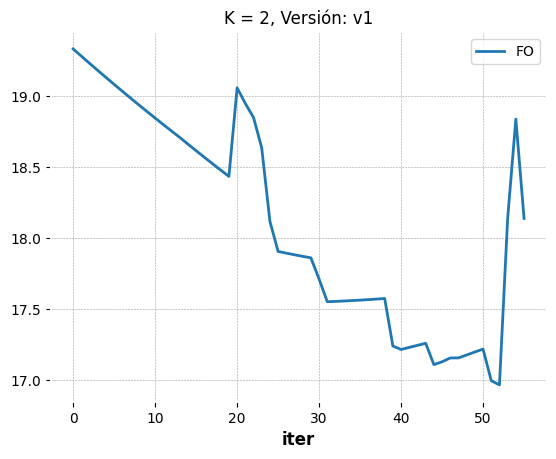

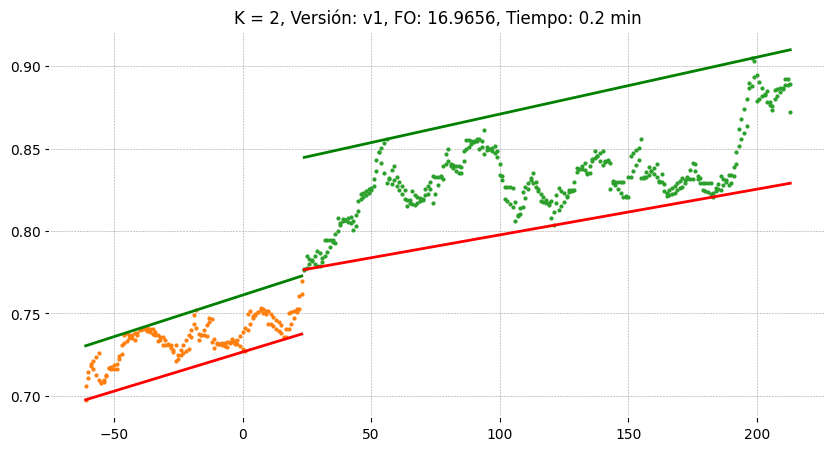

optimo_encontrado


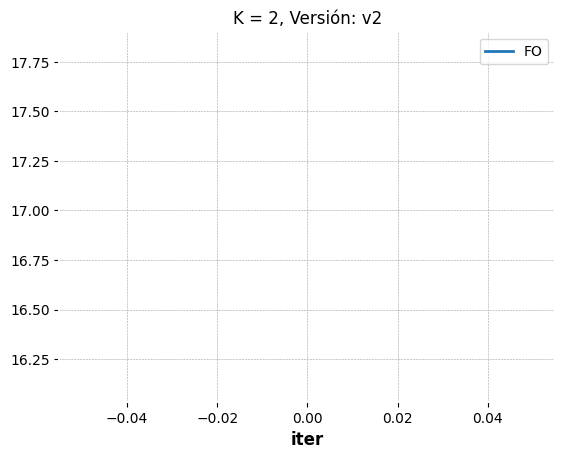

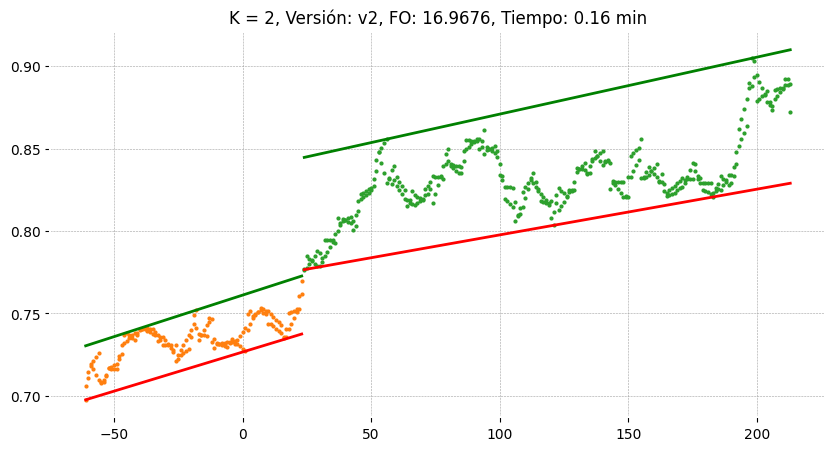

Ya se ha encontrado este ciclo...comenzaría a hacer un loop
{0: -61.0, 1: 43.0, 2: 99.0, 3: 213.0}
{'-61.0_43.0_99.0_213.0_14.4919', '-61.0_30.0_114.0_213.0_14.5328', '-61.0_29.0_121.0_213.0_14.9687', '-61.0_30.0_118.0_213.0_14.7395', '-61.0_33.0_103.0_213.0_14.0323', '-61.0_31.0_115.0_213.0_14.6536', '-61.0_39.0_101.0_213.0_14.4348', '-61.0_41.0_101.0_213.0_14.4531', '-61.0_40.0_100.0_213.0_14.056', '-61.0_29.0_119.0_213.0_14.7909', '-61.0_28.0_120.0_213.0_14.9356', '-61.0_43.0_101.0_213.0_14.4745', '-61.0_30.0_112.0_213.0_14.8553', '-61.0_44.0_100.0_213.0_14.8924', '-61.0_31.0_107.0_213.0_14.8317', '-61.0_31.0_113.0_213.0_14.6995', '-61.0_30.0_116.0_213.0_14.5893', '-61.0_36.0_102.0_213.0_13.7092', '-61.0_30.0_106.0_213.0_14.7128', '-61.0_32.0_104.0_213.0_14.2534', '-61.0_31.0_109.0_213.0_14.8805', '-61.0_34.0_102.0_213.0_14.0081', '-61.0_31.0_105.0_213.0_14.437', '-61.0_42.0_100.0_213.0_14.0758', '-61.0_31.0_117.0_213.0_14.708', '-61.0_30.0_108.0_213.0_14.7632', '-61.0_38.0_100.0_21

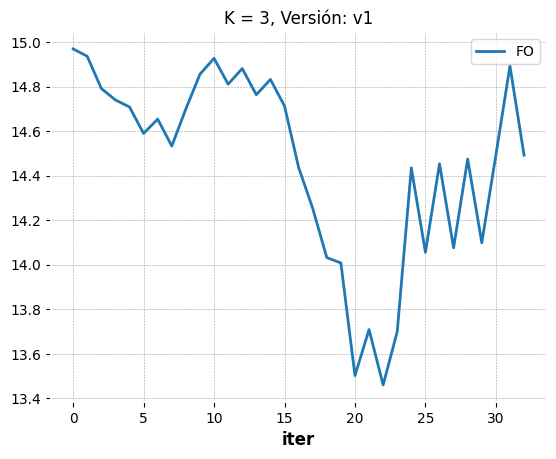

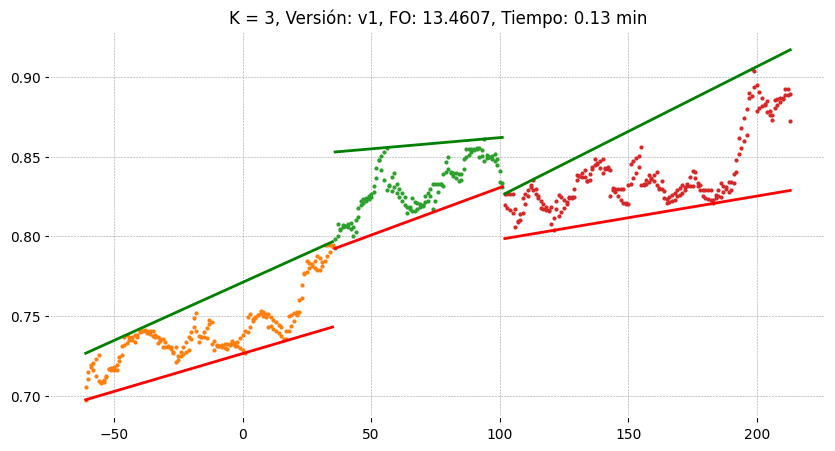

Error en factibilidad del modelo
optimo_encontrado


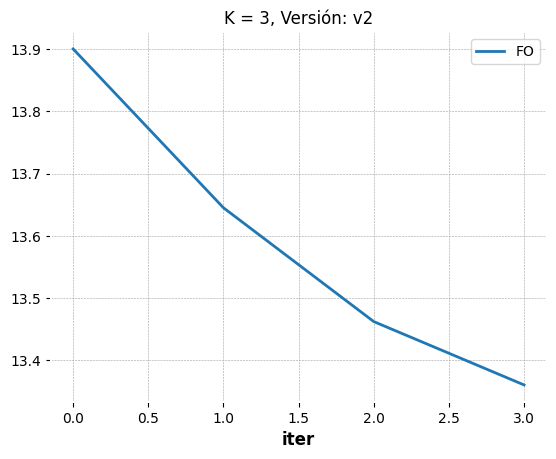

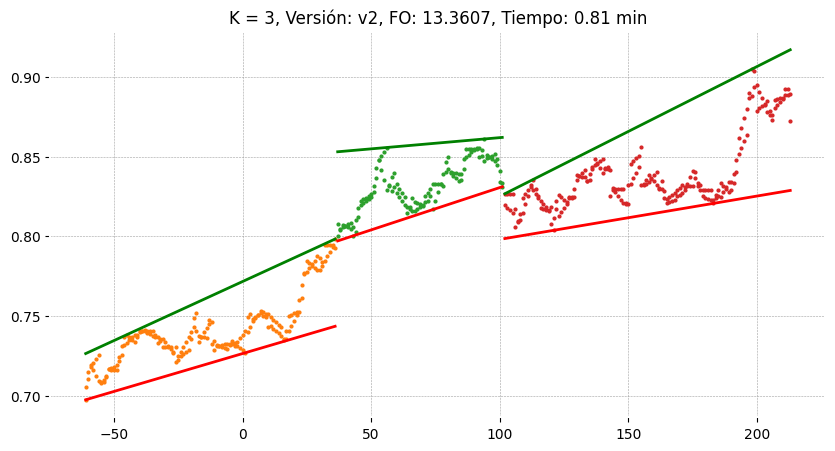

Ya se ha encontrado este ciclo...comenzaría a hacer un loop
{0: -61.0, 1: -13.0, 2: 85.0, 3: 111.0, 4: 213.0}
{'-61.0_-13.0_79.0_115.0_213.0_14.0483', '-61.0_-6.0_68.0_130.0_213.0_13.2751', '-61.0_-13.0_83.0_113.0_213.0_14.3164', '-61.0_5.0_73.0_141.0_213.0_13.5295', '-61.0_4.0_72.0_140.0_213.0_13.5137', '-61.0_-13.0_77.0_123.0_213.0_13.9031', '-61.0_-12.0_78.0_118.0_213.0_14.0897', '-61.0_7.0_75.0_143.0_213.0_13.7429', '-61.0_-13.0_79.0_121.0_213.0_13.8792', '-61.0_-12.0_78.0_120.0_213.0_14.1066', '-61.0_-7.0_69.0_129.0_213.0_13.1765', '-61.0_-10.0_72.0_126.0_213.0_13.1369', '-61.0_-13.0_79.0_119.0_213.0_14.0704', '-61.0_-3.0_65.0_133.0_213.0_13.305', '-61.0_-12.0_86.0_112.0_213.0_14.5058', '-61.0_-12.0_86.0_112.0_213.0_14.4475', '-61.0_-13.0_79.0_113.0_213.0_14.1342', '-61.0_-9.0_71.0_127.0_213.0_13.1057', '-61.0_3.0_71.0_139.0_213.0_13.662', '-61.0_-13.0_85.0_113.0_213.0_14.3637', '-61.0_2.0_70.0_138.0_213.0_13.7472', '-61.0_-5.0_67.0_131.0_213.0_13.2455', '-61.0_-12.0_80.0_112.0_21

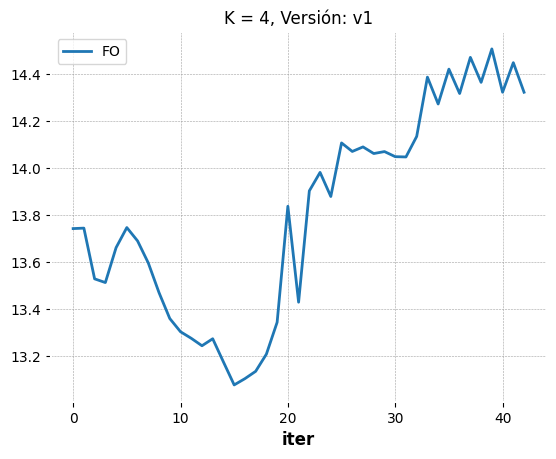

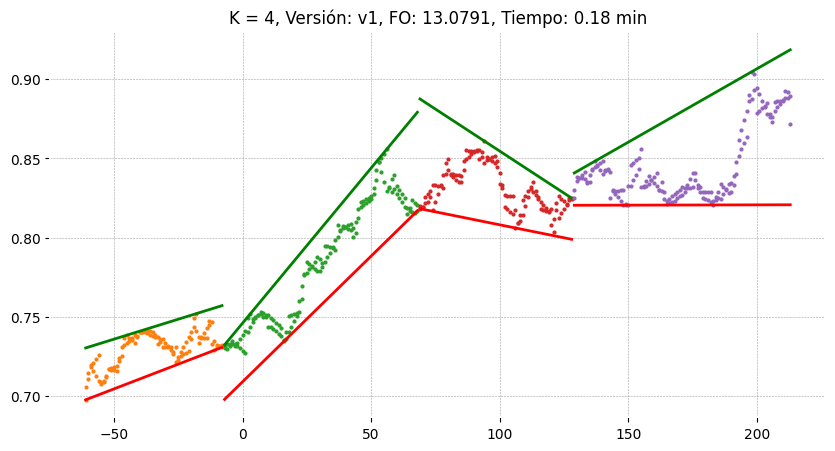

Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
optimo_encontrado


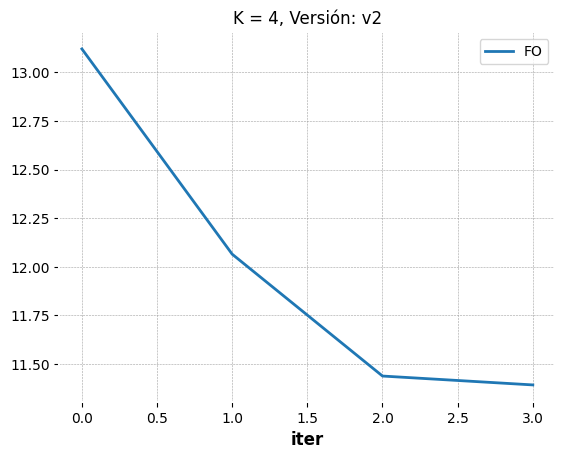

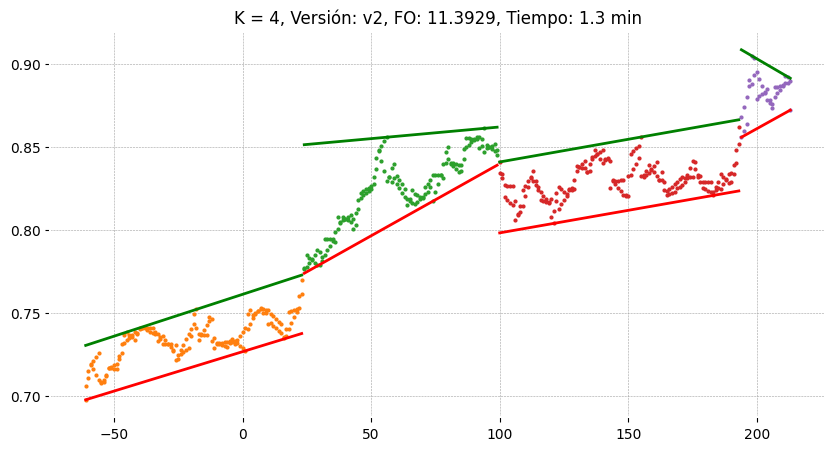

Ya se ha encontrado este ciclo...comenzaría a hacer un loop
{0: -61.0, 1: 20.0, 2: 57.0, 3: 103.0, 4: 156.0, 5: 213.0}
{'-61.0_-1.0_54.0_104.0_155.0_213.0_11.2223', '-61.0_20.0_57.0_103.0_156.0_213.0_11.2334', '-61.0_7.0_56.0_102.0_155.0_213.0_10.9162', '-61.0_9.0_56.0_102.0_155.0_213.0_10.8389', '-61.0_16.0_57.0_103.0_156.0_213.0_11.242', '-61.0_1.0_56.0_104.0_155.0_213.0_11.2985', '-61.0_18.0_57.0_103.0_156.0_213.0_11.2504', '-61.0_-2.0_53.0_103.0_156.0_213.0_11.5007', '-61.0_5.0_56.0_102.0_155.0_213.0_10.9694', '-61.0_19.0_56.0_102.0_155.0_213.0_10.6537', '-61.0_17.0_56.0_102.0_155.0_213.0_10.7097', '-61.0_15.0_56.0_102.0_155.0_213.0_10.7012', '-61.0_11.0_56.0_102.0_155.0_213.0_10.7078', '-61.0_12.0_57.0_103.0_156.0_213.0_11.2279', '-61.0_8.0_57.0_103.0_156.0_213.0_11.4405', '-61.0_14.0_57.0_103.0_156.0_213.0_11.2345', '-61.0_0.0_55.0_103.0_156.0_213.0_11.7299', '-61.0_13.0_56.0_102.0_155.0_213.0_10.6933', '-61.0_-5.0_50.0_104.0_157.0_213.0_11.1281', '-61.0_6.0_57.0_103.0_156.0_213.

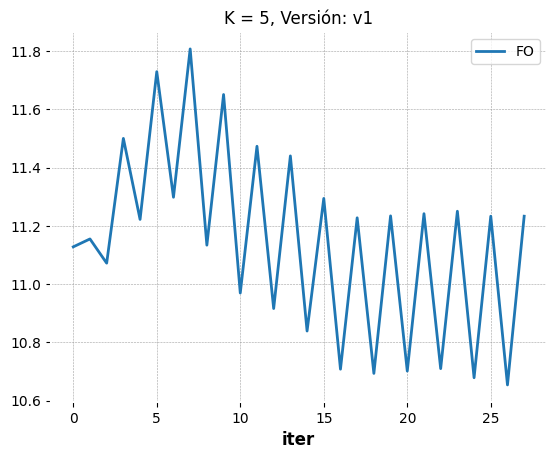

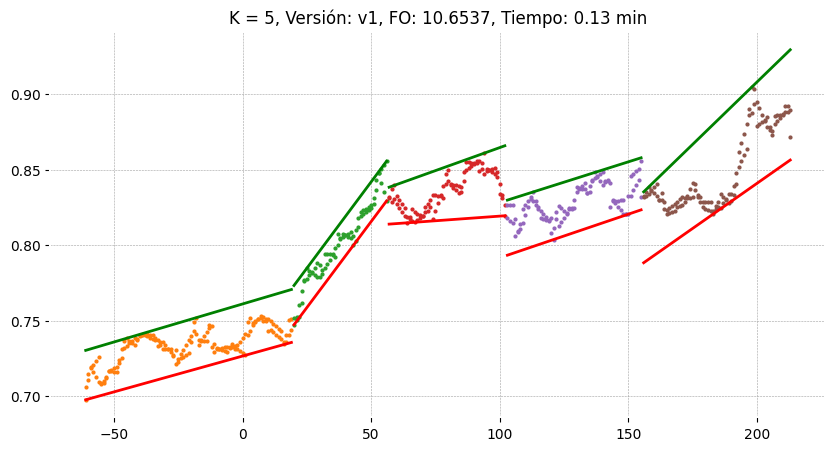

Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en f

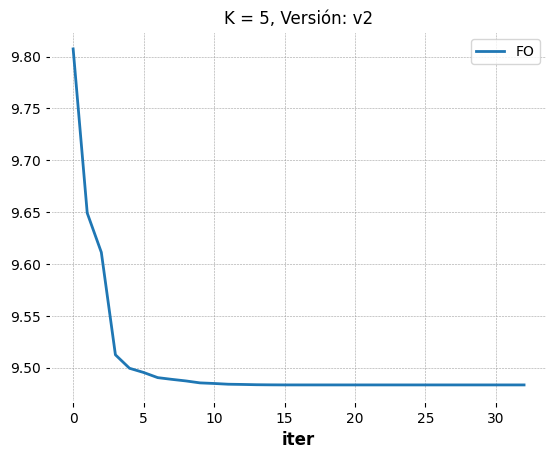

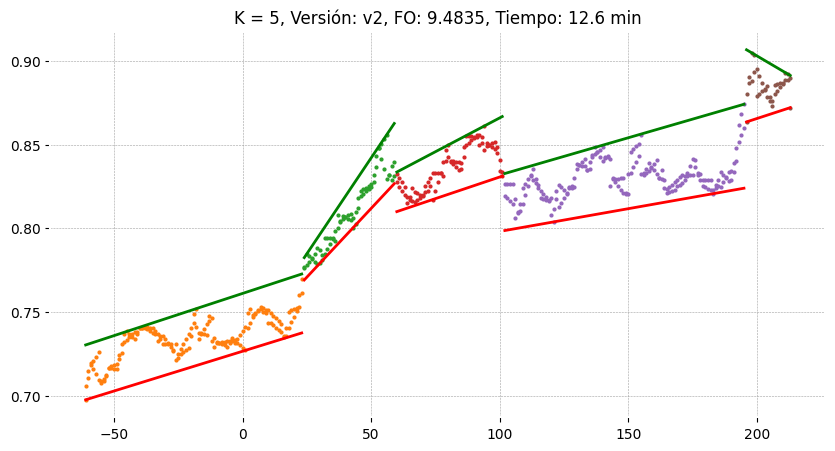

Ya se ha encontrado este ciclo...comenzaría a hacer un loop
{0: -61.0, 1: 2.0, 2: 19.0, 3: 61.0, 4: 135.0, 5: 140.0, 6: 213.0}
{'-61.0_-3.0_14.0_64.0_134.0_151.0_213.0_12.2175', '-61.0_-15.0_22.0_68.0_130.0_159.0_213.0_11.1976', '-61.0_-14.0_21.0_67.0_129.0_158.0_213.0_11.3297', '-61.0_-9.0_16.0_66.0_130.0_153.0_213.0_12.0807', '-61.0_-11.0_18.0_66.0_130.0_155.0_213.0_11.4853', '-61.0_-17.0_28.0_74.0_124.0_165.0_213.0_11.3382', '-61.0_-18.0_25.0_71.0_127.0_162.0_213.0_11.2513', '-61.0_-12.0_19.0_65.0_129.0_156.0_213.0_11.3953', '-61.0_1.0_18.0_60.0_136.0_145.0_213.0_11.9953', '-61.0_-8.0_15.0_67.0_129.0_152.0_213.0_12.0444', '-61.0_1.0_18.0_62.0_136.0_141.0_213.0_12.1788', '-61.0_-16.0_29.0_75.0_123.0_166.0_213.0_11.3354', '-61.0_1.0_18.0_62.0_136.0_141.0_213.0_11.9686', '-61.0_-1.0_16.0_62.0_136.0_149.0_213.0_12.0384', '-61.0_2.0_19.0_61.0_137.0_144.0_213.0_11.909', '-61.0_-17.0_26.0_72.0_126.0_163.0_213.0_11.3618', '-61.0_-13.0_20.0_66.0_130.0_157.0_213.0_11.3972', '-61.0_-6.0_15.0_6

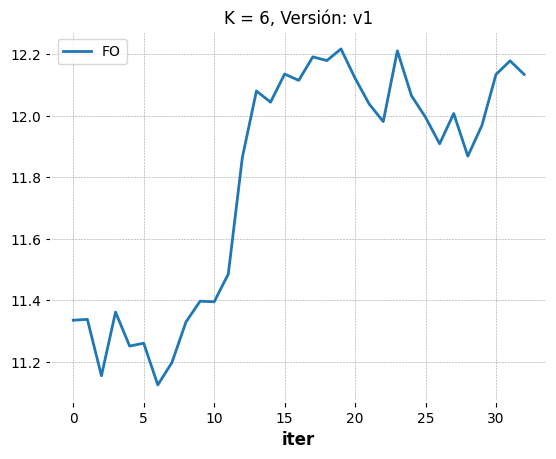

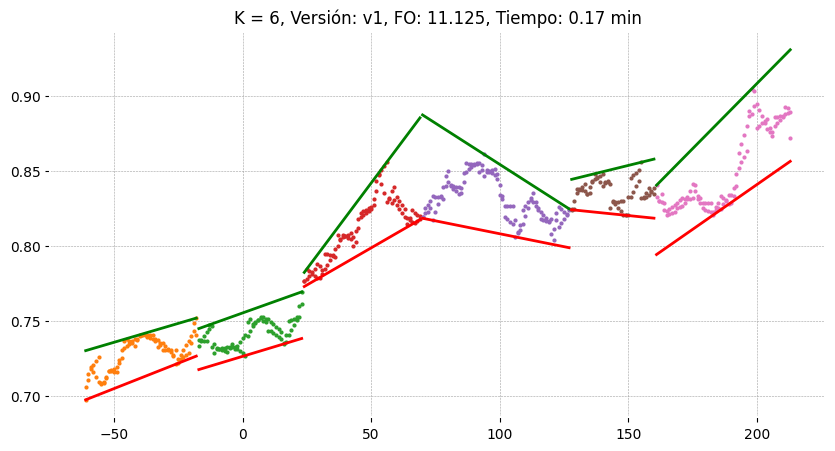

Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en f

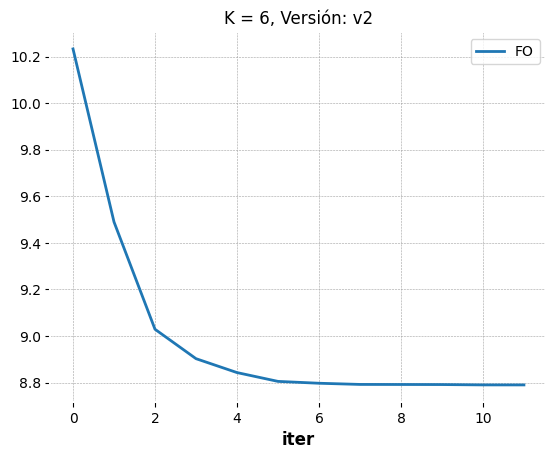

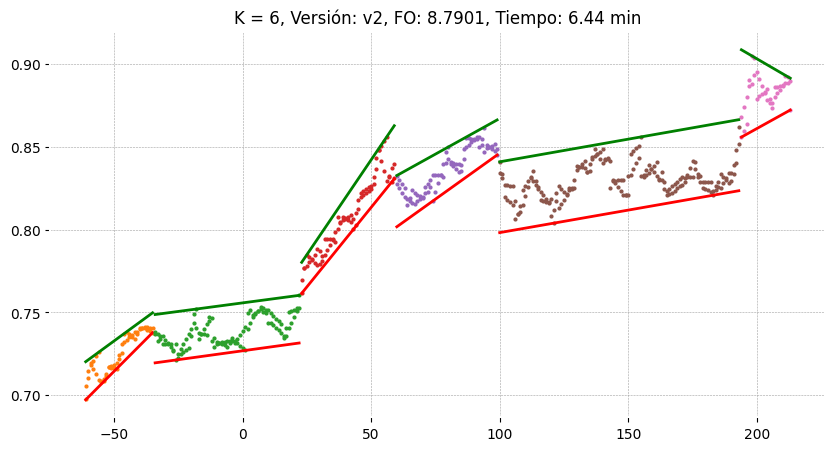

Ya se ha encontrado este ciclo...comenzaría a hacer un loop
{0: -61.0, 1: -18.0, 2: 7.0, 3: 60.0, 4: 100.0, 5: 135.0, 6: 140.0, 7: 213.0}
{'-61.0_-18.0_11.0_58.0_104.0_127.0_166.0_213.0_9.4895', '-61.0_-17.0_8.0_61.0_101.0_136.0_145.0_213.0_10.4454', '-61.0_-17.0_8.0_59.0_101.0_136.0_147.0_213.0_10.2981', '-61.0_-18.0_9.0_56.0_104.0_133.0_150.0_213.0_10.3644', '-61.0_-17.0_10.0_57.0_107.0_128.0_155.0_213.0_10.3031', '-61.0_-18.0_7.0_60.0_100.0_135.0_144.0_213.0_10.4616', '-61.0_-18.0_7.0_60.0_100.0_135.0_140.0_213.0_10.5136', '-61.0_-18.0_9.0_56.0_106.0_127.0_160.0_213.0_10.0624', '-61.0_-18.0_9.0_56.0_102.0_135.0_150.0_213.0_10.3028', '-61.0_-18.0_13.0_60.0_102.0_129.0_168.0_213.0_9.3229', '-61.0_-18.0_9.0_56.0_106.0_127.0_162.0_213.0_9.9192', '-61.0_-20.0_17.0_58.0_98.0_133.0_172.0_213.0_9.5211', '-61.0_-17.0_10.0_57.0_107.0_128.0_157.0_213.0_10.2829', '-61.0_-17.0_10.0_57.0_103.0_134.0_151.0_213.0_10.679', '-61.0_-18.0_9.0_58.0_100.0_135.0_148.0_213.0_10.1624', '-61.0_-18.0_9.0_56.0

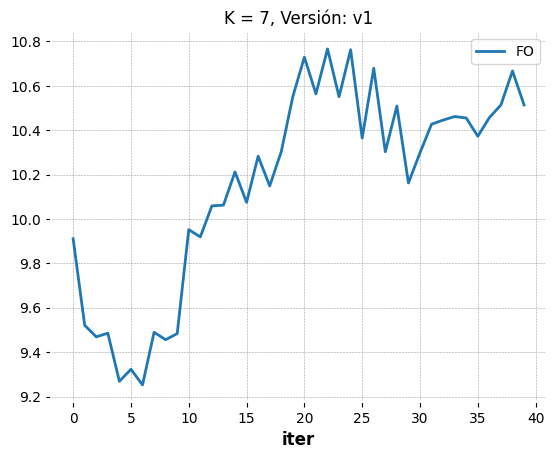

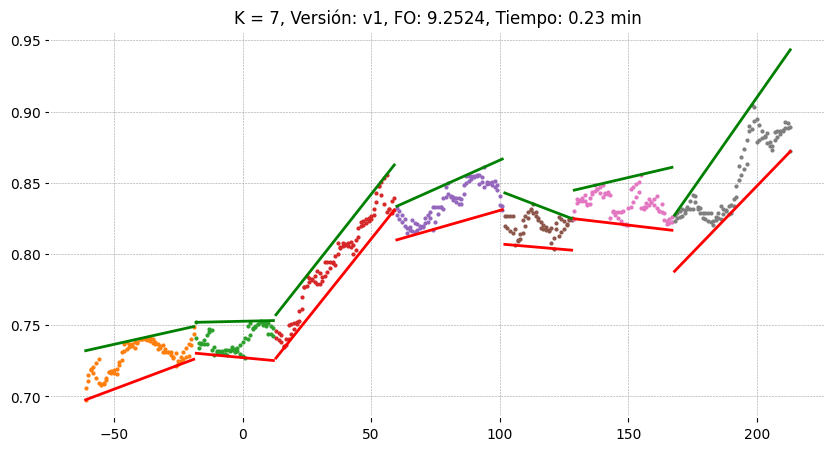

Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en f

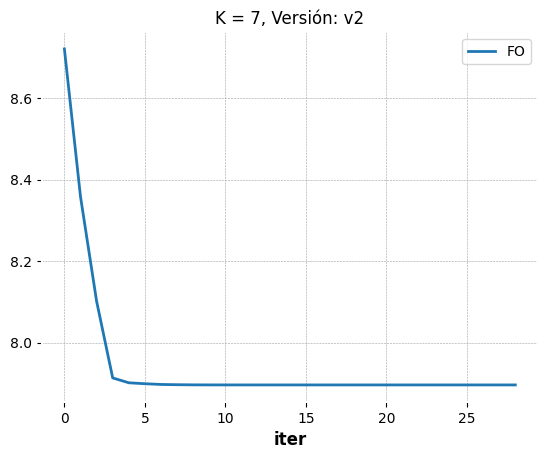

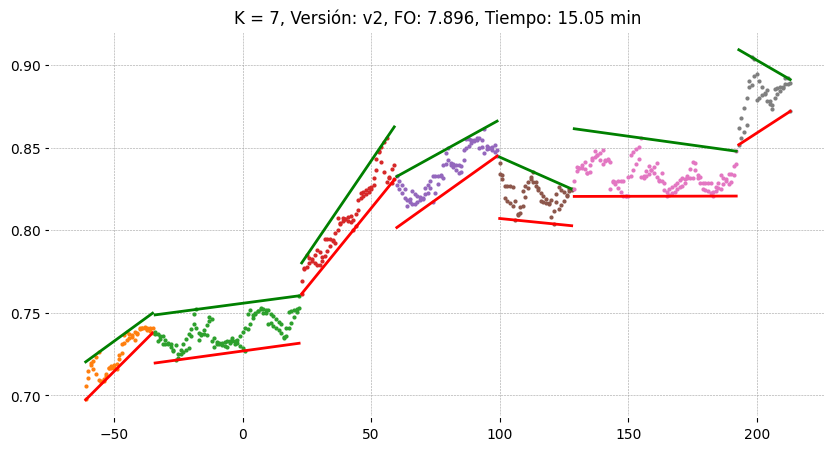

Ya se ha encontrado este ciclo...comenzaría a hacer un loop
{0: -61.0, 1: -18.0, 2: 19.0, 3: 53.0, 4: 75.0, 5: 101.0, 6: 165.0, 7: 168.0, 8: 213.0}
{'-61.0_-18.0_19.0_53.0_75.0_101.0_155.0_172.0_213.0_8.8784', '-61.0_-25.0_10.0_44.0_76.0_108.0_146.0_177.0_213.0_9.6998', '-61.0_-17.0_18.0_52.0_74.0_100.0_160.0_167.0_213.0_9.1074', '-61.0_-17.0_18.0_52.0_74.0_100.0_164.0_167.0_213.0_9.2494', '-61.0_-17.0_18.0_52.0_74.0_100.0_164.0_167.0_213.0_9.2981', '-61.0_-18.0_19.0_53.0_75.0_101.0_159.0_168.0_213.0_9.0405', '-61.0_-21.0_14.0_48.0_74.0_104.0_150.0_175.0_213.0_9.4663', '-61.0_-24.0_11.0_45.0_77.0_107.0_147.0_176.0_213.0_9.8442', '-61.0_-19.0_16.0_50.0_74.0_102.0_150.0_175.0_213.0_9.2577', '-61.0_-18.0_19.0_53.0_75.0_101.0_165.0_168.0_213.0_9.2091', '-61.0_-18.0_19.0_53.0_75.0_101.0_153.0_174.0_213.0_8.9153', '-61.0_-23.0_12.0_46.0_76.0_106.0_148.0_175.0_213.0_9.6226', '-61.0_-18.0_17.0_51.0_75.0_101.0_151.0_176.0_213.0_9.0754', '-61.0_-17.0_18.0_52.0_74.0_100.0_158.0_169.0_213.0_9.0335

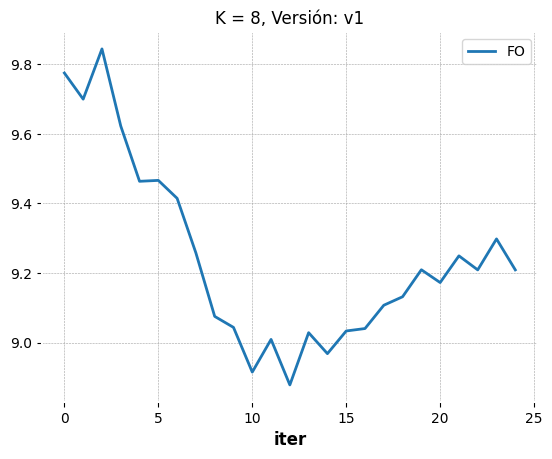

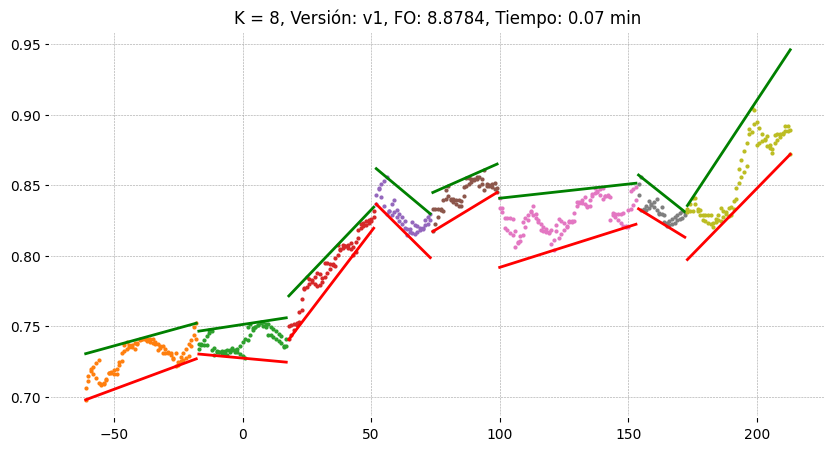

Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en factibilidad del modelo
Error en f

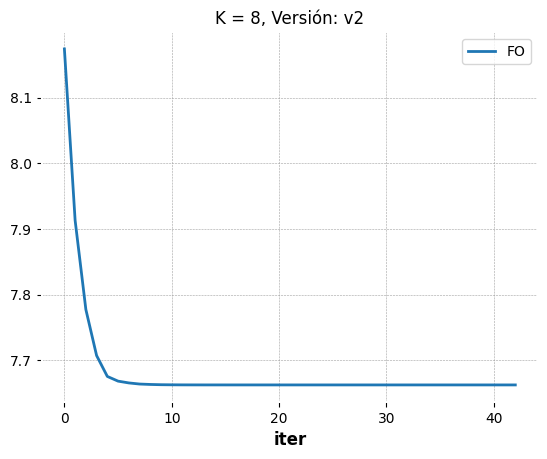

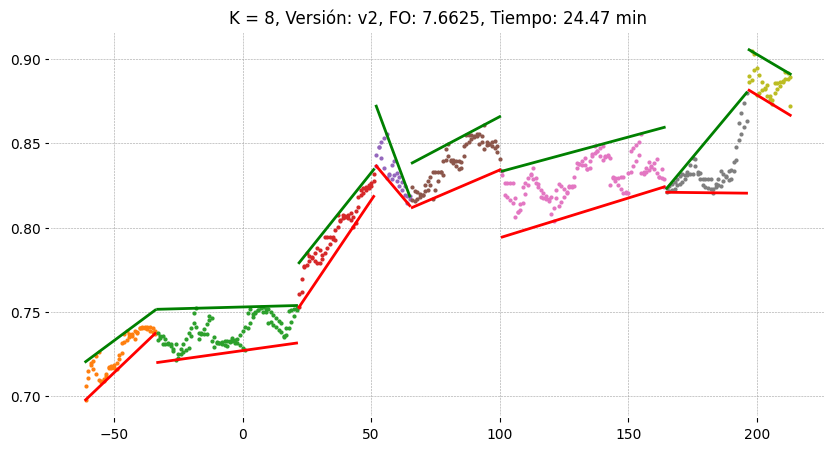

In [159]:
gamma_value = 60000
paralelas = False
segmentos_conjuntos = False
df_all_results = pd.DataFrame()

for K in [2, 3, 4, 5, 6, 7, 8]:
    dic_t = crear_dic_t_incial(df, K)
    for version in ['v1', 'v2']:
        t0 = time.time()
        best_dic_t, best_FO, df_z = Modelo_chartista(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos)
        t_all = (time.time() - t0) / 60
        # Mejor modelo
        df_z.plot(x = 'iter', y = 'FO', title = f'K = {K}, Versión: {version}') # plot F.O. evolución
        X = corregir_X(X, best_dic_t)
        
        #print('Best t optimo 1', best_FO,  best_dic_t)
        df_resultados, best_FO = generate_all_figure(X, best_dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
        dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        #print('Best t optimo 2', best_FO,  best_dic_t)
        
        #print('Grafico óptimo')
        graficar(X, K, dic_puntos, titulo = f'K = {K}, Versión: {version}, FO: {round(best_FO, 4)}, Tiempo: {round(t_all, 2)} min')
        
        df_results_new = pd.DataFrame({'K': [K], 'Version': [version], 'FO': [best_FO], 'Tiempo': [t_all]})
        df_all_results = pd.concat([df_all_results, df_results_new], axis = 0)
        
        #sys.exit('Continuar acá 240725: Ejecutar todo de nuevo, eliminar tantas impresiones de gráficos y otras coasas e ir probando como se ven los resultados en cada iteración')
        

# Mejor modelo

In [160]:
sys.exit()

SystemExit: 

In [ ]:
best_dic_t

In [ ]:
# plotear df_z
df_z.plot(x = 'iter', y = 'FO')

In [ ]:
X['k'] = X['t'].apply(lambda t: sum([t >= best_dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo

#graficar(X, K)

# Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

# NUEVO: Encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)
#X = X.rename(columns = {'k_grupo': 'k'})
X['k'] = X['k'].astype(int)
X = X.sort_values(by = 't').reset_index(drop = True)

In [ ]:
df_resultados, FO = generate_all_figure(X, best_dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
FO


In [ ]:
dic_puntos, dic_holguras = {}, {}
for k in range(1, K + 1):
    dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
    dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
dic_puntos

In [ ]:
graficar(X, K, dic_puntos)

In [ ]:
sys.exit()

In [ ]:
# Mejores FOs algoritmo:

#k = 4 -> 11.1257579209791

In [ ]:
best_FO = 15.870443467963696
dic_t_optimo = {0: -61.0, 1: 35.0, 2: 204.0}

In [ ]:
# v3
best_FO = 12.58243629
dic_t_optimo = {0: -61.0, 1: 38.0, 2: 101.0, 3: 204.0}

In [ ]:
dic_t

In [ ]:
X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)]))

In [ ]:
[dic_t[k] for k in range(K)]

In [ ]:
X.info()

In [ ]:
X[X.index == 246]

In [ ]:
sys.exit()

# Antiguo

In [ ]:
# NUEVO: Encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

gamma_value = 60
X = X.rename(columns = {'k_grupo': 'k'})
X['k'] = X['k'].astype(int)
X = X.sort_values(by = 't').reset_index(drop = True)
paralelas = False
segmentos_conjuntos = True

iters = 100
for i in range(iters):
    df_resultados = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos)

    dic_puntos, dic_holguras = {}, {}
    for k in range(1, K + 1):
        dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
        dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
        #dic_puntos[k] = {'B0L': B0L, 'B1L': B1L, 'B0U': B0U, 'B1U': B1U}

    graficar(X, K, dic_puntos)
    dic_t = update_dic_t(K, dic_puntos, gamma_value, dic_holguras) # funcion objetivo y gradient descent

In [ ]:
# Continuar acá 240705: revisar codigo en: C:\Users\mvaldiviad\OneDrive - Falabella\Escritorio\Proyectos Personales\Apuestas Deportivas\teorico_mean_and_desv.ipynb para saber como usar sympy
# una vez encontradas, plantear la función objetivo solo en función de la variable t_k

# TO DO

# [OK] Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i

# [OK] revisar codigo en: C:\Users\mvaldiviad\OneDrive - Falabella\Escritorio\Proyectos Personales\Apuestas Deportivas\teorico_mean_and_desv.ipynb para saber como usar sympy

# [OK] una vez encontradas, plantear la función objetivo solo en función de la variable t_k

# [OK] Descenso del gradiente

# [Mejorar! no está convergiendo bien] Iterar hasta la convergencia (continuar aca el 240708)

# Revisar como cambia la FO, para distintos valores de K y gamma. Ver las rectas  y el cambio de FO, gráficamente


# Función objetivo general

In [ ]:
from sympy import *

def update_dic_t(K, learning_rate = 0.01):
    #beta0L, beta1L, beta0U, beta1U, t, A, gamma, R1, R2, B1, B2, H, i, N = symbols("beta0L beta1L beta0U beta1U t A gamma R1 R2 B1 B2 H i N")
    gamma = symbols("gamma")

    B1, B2, H, A, Holguras = {}, {}, {}, {}, {}
    S = 0
    #K = 2
    for k in range(1, K + 1):
        print(k)
        B1[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k - 1)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k - 1))
        B2[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k))
        H[k] = Indexed('t', k) - Indexed('t', k - 1)
        A[k] = (B1[k] + B2[k]) * H[k] / 2
        Holguras[k] = gamma * (Indexed('R1', k) + Indexed('R2', k))
        S += (A[k] + Holguras[k])

    # eval en S (se reemplazan los valores de las variables beta, gamma y Holguras (R))

    for k in range(1, K + 1):
        S = S.evalf(subs = {Indexed('beta0L', k): dic_puntos[k]['B0L'], # Recta inf
                        Indexed('beta1L', k): dic_puntos[k]['B1L'], 
                        Indexed('beta0U', k): dic_puntos[k]['B0U'], # Recta sup
                        Indexed('beta1U', k): dic_puntos[k]['B1U'], 
                        gamma: gamma_value, # gamma
                        Indexed('R1', k): dic_holguras[k]['HL'], # Holguras
                        Indexed('R2', k): dic_holguras[k]['HU']})

    # Gradient Descent
    
    for k in range(1, K):
        D = diff(S, Indexed('t', k))
        D = D.evalf(subs = {Indexed('t', k): dic_t[k]})
        print(D)
        
        dic_t[k] = dic_t[k] - learning_rate * D
    
    return dic_t



In [ ]:
sys.exit()

In [ ]:
# ANTIGUO: Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

dic_puntos = {}
gamma = 1000

df_resultados = generate_all_figure(X, dic_t, gamma)
display(df_resultados)
for k in range(1, K + 1):
    dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
    #dic_puntos[k] = {'B0L': B0L, 'B1L': B1L, 'B0U': B0U, 'B1U': B1U}

graficar(X, K, dic_puntos)

# TO DO

# Otros

In [ ]:
# 1. generate_figure (original, para un solo trapecio)
def generate_figure(data_points, output = True, slope_inf = 'libre', slope_sup = 'libre', paralelas = False):

    '''
    :param data_points: Nube de puntos con los campos x | y
    :type: dataframe
    '''

    # CONFIGURACION
    
    # figura libre: libre, libre, False
    # canal: libre, libre, True
    # arriba pendiente 0: 0, libre, False
    # abajo pendiente 0: libre, 0, False
    # arriba y abajo pendiente 0: 0, 0, False/True

    if (slope_inf == '0') and (slope_sup == '0'):
        variables = {'B0L': [data_points['y'].min()], 'B1L': [0], 'B0U': [data_points['y'].max()], 'B1U': [0]}
        df_variables = pd.DataFrame(variables)
        return df_variables

    data_points = data_points.reset_index(drop = True)
    
    mip_model = mip.Model()
    # Variables
    variables = {}
    for v in ['B0L', 'B1L', 'B0U', 'B1U']:
        variables[v] = mip_model.add_var(var_type = 'C', name = v)

    # Restriccion de puntos
    for i in range(len(data_points)):
        x, y = data_points['x'][i], data_points['y'][i]

        R1 = (variables['B0U'] + variables['B1U'] * x >= y)
        R2 = (variables['B0L'] + variables['B1L'] * x <= y)
        mip_model += R1
        mip_model += R2

    # Restricciones de figuras
    if slope_inf == '0':
        R3 = (variables['B1L'] == 0)
        mip_model += R3
    if slope_sup == '0':
        R4 = (variables['B1U'] == 0)
        mip_model += R4
    if paralelas:
        R5 = (variables['B1L'] == variables['B1U'])
        mip_model += R5

    # Funcion objetivo (minimizar el area del trapecio formado (altura horizontal:h)) -> Min (base_left + base_right) * h / 2 <-> Min (base_left + base_right)
    t0, tf = data_points['x'].min(), data_points['x'].max()
    base_left = variables['B0U'] + variables['B1U'] * t0 - (variables['B0L'] + variables['B1L'] * t0)
    base_right = variables['B0U'] + variables['B1U'] * tf - (variables['B0L'] + variables['B1L'] * tf)

    Z = base_left + base_right
    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE) and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND) and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            variables[v] = [variables[v].x]

        df_variables = pd.DataFrame(variables)
        return df_variables

    else:
        print('Error en factibilidad del modelo')
        return pd.DataFrame({})